<a href="https://colab.research.google.com/github/noraberinger/FeatureEngineering_HS2026/blob/main/02_Feature_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/mse_logo.png" width="400" align="right"/>
<div style="text-align: left"> <b> Machine Learning FTP_MachLe </b> <br> HS 2026 <br> <a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

In [1]:
# imports
from IPython.display import Image, display
from IPython.display import HTML
import os
import requests
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# allow plots to appear directly in the notebook
%matplotlib inline

# raw URL of this repository on GitHub (images, data)
filepath = "https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main"

# **Feature Engineering – Group 2: Feature Transformation**

**Authors:** *Name 1, Name 2, Name 3, ...*

<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/images/02_Feature_Transformation.png" width="1200"/>

## Introduction

**What is it about?**
*Feature transformation* changes the representation of a feature so that a model can use it more easily. Monotonic transforms such as the logarithm or the square root compress long-tailed distributions and turn multiplicative effects into additive ones. Categorical variables must be turned into numbers, via one-hot encoding for nominal and label (ordinal) encoding for ordered categories. Polynomial features let linear models capture non-linear relationships, and periodic features such as time of day, weekday or angle are best encoded with sine/cosine pairs or radial basis functions so that "23:59" and "00:01" end up close together.

**Where is it used?**
Everywhere tabular data is modelled: prices and incomes (log transform), customer or product categories (one-hot encoding), physical models with interactions (polynomial features), and time series with daily, weekly or seasonal cycles such as energy demand, traffic or sales forecasting (cyclic encoding).

**Why is it important for Machine Learning?**
Most learners make implicit assumptions about their inputs: linear models assume linear effects, distance-based models assume meaningful distances, and no model can directly digest strings. A well-chosen transformation can turn a hard problem into an easy one, often with a simpler model. A poorly chosen one (e.g. label-encoding nominal categories or blindly one-hot encoding high-cardinality features) introduces false orderings, sparsity and the curse of dimensionality.

## (i) Why and when feature transformations make sense



## (ii) Log, square root, and monotonic transforms



## (iii) Categorical features: nominal → one-hot encoding, ordinal → label encoding



## (iv) Problems with one-hot encoding (sparsity, curse of dimensionality)

While One-Hot Encoding (OHE) is essential for converting nominal categorical variables into numeric values without imposing artificial order, it exhibits critical limitations when applied to **high-cardinality features** (categorical features with many unique categories, like Zip Codes, Product IDs, or Usernames).

### Core Issues

1. **High Sparsity (Data Matrix Explosion)**
   - When a feature with $K$ unique categories is one-hot encoded, it creates $K$ new binary columns.
   - For any given sample, exactly **one column will contain a `1` and $K-1$ columns will contain `0`s**.
   - As $K$ grows, the feature matrix becomes overwhelmingly populated by zeros. This wastes huge amounts of RAM and computation time unless specialized sparse matrices are used.

2. **The Curse of Dimensionality**
   - Adding dozens, hundreds, or thousands of sparse columns drastically increases the volume of the feature space.
   - **Overfitting:** Machine learning models (especially linear models, decision trees, and distance-based algorithms) become prone to finding spurious patterns in tiny subsets of data.
   - **Computational Strain:** Algorithmic training times scale linearly or quadratically with the number of features $D$.
   - **Distance Degradation:** In algorithms like $k$-NN or SVMs, pairwise distances between data points become uniform and meaningless in hyper-dimensional spaces.

3. **Multicollinearity (The Dummy Variable Trap)**
   - Full one-hot encoding creates $K$ features whose sum is always equal to 1 for every row.
   - This exact linear dependency makes feature matrices singular (non-invertible), breaking classical linear and logistic regression models unless one column is dropped (`drop='first'`) or explicit regularization ($L_1$/$L_2$) is applied.

---

### Practical Alternatives to High-Cardinality One-Hot Encoding

* **Frequency / Count Encoding:** Replace categories with their frequency or count in the dataset.
* **Target / Mean Encoding:** Replace each category with the average value of the target variable for that category (requires smoothing/cross-validation to prevent target leakage).
* **Feature Hashing (The Hashing Trick):** Hash categories into a fixed, smaller number of buckets ($N$ dimensions).
* **Entity Embeddings:** Learn low-dimensional dense continuous vectors using Neural Networks.
* **Rare Category Grouping:** Combine infrequently occurring categories into a single `"Other"` bucket prior to encoding.

## References

1. Scikit-learn Documentation – `OneHotEncoder`**: Details on one-hot/dummy encoding implementations, sparse matrix outputs, and handling high-cardinality features.  
   URL: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

2. Feature-engine Documentation – Categorical Encoding**: Overview of high cardinality, data sparsity, rare label encoding, and alternatives to standard One-Hot Encoding.  
   URL: https://feature-engine.trainindata.com/en/1.8.x/user_guide/encoding/index.html

3. Zheng, A., & Casari, A. (2018)**. *Feature Engineering for Machine Learning: Principles and Techniques for Data Prep*. O'Reilly Media. (Chapter 3: *Building Features: Encoding Categorical Variables*).

Original shape: (1000, 1)
Encoded shape:  (1000, 100)
Matrix Sparsity: 99.00% zeros



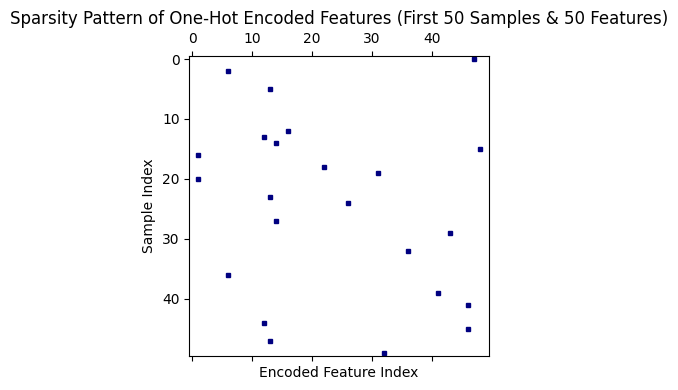

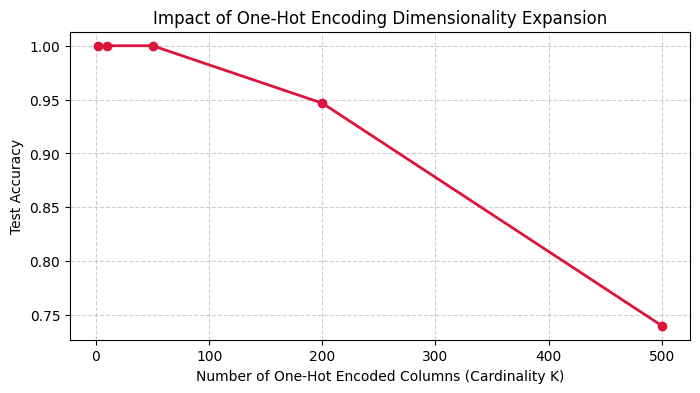

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------
# 1. Visualizing Sparsity & Dimensionality Expansion
# ---------------------------------------------------------
# Create a dummy dataset with high-cardinality features
np.random.seed(42)
n_samples = 1000
high_cardinality_feature = np.random.choice([f"Category_{i}" for i in range(100)], size=n_samples)

df_demo = pd.DataFrame({"HighCard_Feature": high_cardinality_feature})

encoder = OneHotEncoder(sparse_output=False)
ohe_matrix = encoder.fit_transform(df_demo[["HighCard_Feature"]])

# Calculate Sparsity
total_elements = ohe_matrix.size
zero_elements = np.sum(ohe_matrix == 0)
sparsity = (zero_elements / total_elements) * 100

print(f"Original shape: {df_demo.shape}")
print(f"Encoded shape:  {ohe_matrix.shape}")
print(f"Matrix Sparsity: {sparsity:.2f}% zeros\n")

# Plot the Sparse Matrix
plt.figure(figsize=(10, 4))
plt.spy(ohe_matrix[:50, :50], markersize=3, color="navy")
plt.title("Sparsity Pattern of One-Hot Encoded Features (First 50 Samples & 50 Features)")
plt.xlabel("Encoded Feature Index")
plt.ylabel("Sample Index")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Impact on Model Performance (Curse of Dimensionality)
# ---------------------------------------------------------
# Simulate model accuracy vs number of encoded noisy categorical features
dimensions = [2, 10, 50, 200, 500]
acc_scores = []

for d in dimensions:
    # Generate random high-cardinality categorical data + binary target
    X_categories = np.random.randint(0, d, size=(500, 1))
    ohe = OneHotEncoder(sparse_output=False)
    X_ohe = ohe.fit_transform(X_categories)

    # Generate target weakly correlated with first few categories
    y = (X_categories.ravel() % 2 == 0).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size=0.3, random_state=42)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(dimensions, acc_scores, marker='o', linewidth=2, color='crimson')
plt.title("Impact of One-Hot Encoding Dimensionality Expansion")
plt.xlabel("Number of One-Hot Encoded Columns (Cardinality K)")
plt.ylabel("Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## (v) Polynomial features



## (vi) Periodic features: sine/cosine encoding and radial basis functions



## Takeaways

- **What should every ML practitioner remember?**
  - ...
- **What are common pitfalls?**
  - ...
- **When does this technique really matter?**
  - ...

## References

*Cite the sources of all figures, diagrams and code snippets (URLs are sufficient).*

1. ...